# Kasus 3 – Fase Paramagnetik (T = 4.0)
## Tujuan

Simulasi ini bertujuan untuk mengimplementasikan algoritma Metropolis pada Model Ising dua dimensi untuk mengamati perilaku sistem pada temperatur tinggi (T = 4.0), yaitu di atas temperatur kritis (Tc ≈ 2,27). Pada kondisi ini diharapkan energi termal mendominasi interaksi antar-spin sehingga orientasi spin menjadi acak dan nilai magnetisasi rata-rata mendekati nol.

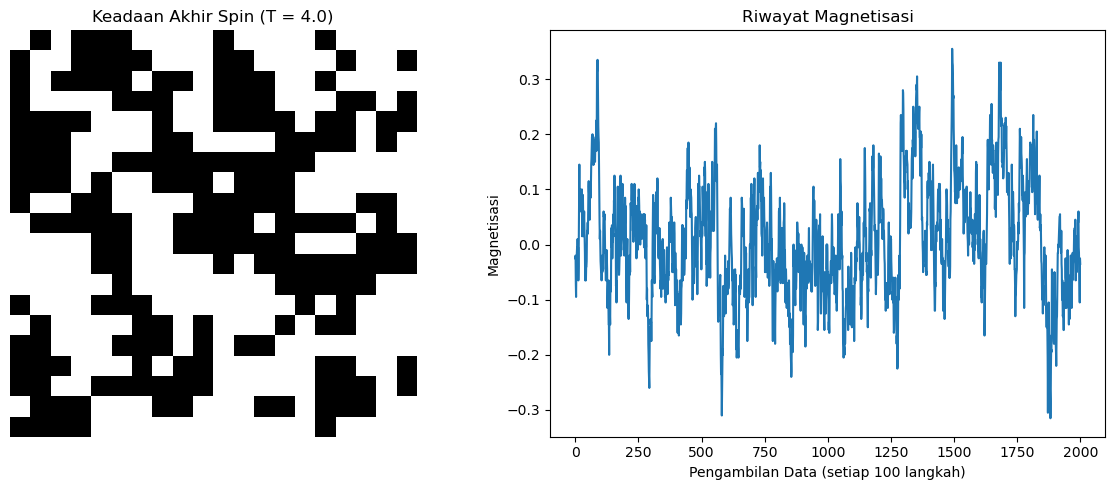

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# ==============================
# PARAMETER SIMULASI
# ==============================

N = 20                 # Ukuran kisi 20 x 20
T = 4.0                # Temperatur tinggi (Paramagnetik)
J = 1                  # Konstanta interaksi
MC_steps = 200000      # Jumlah Monte Carlo Step
interval = 100         # Interval penyimpanan magnetisasi
# ==============================
# HOT START
# ==============================

# Konfigurasi awal acak

spin = np.random.choice([-1, 1], size=(N, N))
# ==============================
# FUNGSI DELTA ENERGI
# ==============================

def delta_energy(lattice, i, j):

    s = lattice[i, j]

    neighbors = (
        lattice[(i + 1) % N, j] +
        lattice[(i - 1) % N, j] +
        lattice[i, (j + 1) % N] +
        lattice[i, (j - 1) % N]
    )

    dE = 2 * J * s * neighbors

    return dE
# ==============================
# ALGORITMA METROPOLIS
# ==============================

magnetisasi = []

for step in range(MC_steps):

    # Memilih spin secara acak
    i = np.random.randint(0, N)
    j = np.random.randint(0, N)

    # Menghitung perubahan energi
    dE = delta_energy(spin, i, j)

    # Aturan Metropolis
    if dE <= 0:
        spin[i, j] *= -1

    else:
        if np.random.rand() < np.exp(-dE / T):
            spin[i, j] *= -1

    # Menyimpan magnetisasi setiap 100 langkah
    if step % interval == 0:
        M = np.sum(spin) / (N * N)
        magnetisasi.append(M)
# ==============================
# VISUALISASI
# ==============================

plt.figure(figsize=(12,5))

# Keadaan akhir spin
plt.subplot(1,2,1)
plt.imshow(spin, cmap='binary')
plt.title("Keadaan Akhir Spin (T = 4.0)")
plt.axis("off")

# Grafik magnetisasi
plt.subplot(1,2,2)
plt.plot(magnetisasi)
plt.title("Riwayat Magnetisasi")
plt.xlabel("Pengambilan Data (setiap 100 langkah)")
plt.ylabel("Magnetisasi")

plt.tight_layout()
plt.show()

# Analisis Kasus 3 (T = 4.0)

Simulasi dilakukan pada temperatur T = 4,0 yang berada di atas temperatur kritis (Tc ≈ 2,27). Pada kondisi ini energi termal jauh lebih besar dibandingkan energi interaksi antar-spin sehingga orientasi setiap spin menjadi hampir sepenuhnya acak.

Selama simulasi menggunakan algoritma Metropolis, perubahan orientasi spin terjadi sangat sering karena probabilitas penerimaan perubahan energi menjadi lebih tinggi pada temperatur besar. Akibatnya, domain magnetik yang mungkin terbentuk akan segera terpecah kembali oleh pengaruh fluktuasi termal.

Grafik magnetisasi menunjukkan bahwa nilai magnetisasi rata-rata berfluktuasi di sekitar nol tanpa kecenderungan menuju +1 maupun −1. Hal ini menunjukkan bahwa tidak terdapat keteraturan global dalam sistem. Walaupun terdapat fluktuasi sesaat, nilainya tetap kecil karena jumlah spin yang mengarah ke atas dan ke bawah hampir seimbang.

Visualisasi keadaan akhir kisi memperlihatkan pola hitam dan putih yang tersebar secara acak di seluruh kisi tanpa adanya domain besar. Fenomena ini merupakan ciri khas fase paramagnetik, yaitu kondisi ketika energi termal mendominasi sehingga korelasi antar-spin menjadi sangat lemah. Hasil simulasi sesuai dengan teori Model Ising yang menyatakan bahwa pada temperatur tinggi sistem kehilangan sifat kemagnetan spontan dan magnetisasi rata-rata mendekati nol.